## Optional Introductory Material
This note discusses the basics of NumPy. If you are familiar with the NumPy library, you can skip this part. 

# NumPy

NumPy, short for "Numerical Python," is a fundamental package for scientific computing in Python. It is widely used in data analysis due to its ability to handle large, multi-dimensional arrays and matrices, along with a variety of mathematical functions that can be applied to these arrays efficiently. NumPy serves as the foundation for many other data science libraries such as Pandas, SciPy, and scikit-learn, making it an essential tool for anyone working with data in Python.

### Key Features of NumPy   

- N-Dimensional Array Object (ndarray): Efficient handling of arrays (1D, 2D, and multi-dimensional).  
- Mathematical Functions: Fast mathematical operations on entire arrays of data without having to write loops  
- Data Simulation: Generate random numbers for simulations and sampling.  
- Linear Algebra Operations: Includes matrix operations, eigenvalue computation, and more.  
- Broadcasting: Simplifies operations on arrays of different shapes.  
- Integration with Other Libraries: Easily integrates with data science libraries like Pandas and SciPy.   

This note will focus on the use of NumPy in data analysis, thus we will examine   

- Fast array-based operations for data wrangling such as subsetting, filtering, transformation, and cleaning.   
- Functions for performing descriptive statistics such as mean, and standard deviation.    
- Ways to combine and restructure datasets.    
- Grouped operations on data.



In [1]:
import numpy as np

## Creating an Array   

A numpy array can be created from a   
- list using np.array()     
- shortcut functions like np.zeros(), np.full()  

### From a list

In [2]:
arr1 = np.array([1, 2, 3, 4, 5])     # 1D Array from a list
arr2 = np.array([[1, 2, 3], 
                 [4, 5, 6]])         # 2D Array from a List of Lists 

### Shortcut functions    

- np.zeros()  
- np.ones()  
- np.empty()  
- np.full()  
- np.linspace()  
- np.random.random(), np.random.randint(), np.random.normal()  
- np.arange()
  

In [3]:
np.zeros((2, 3))       # 2x3 2D Array of zeros
np.ones((2, 3))        # 2x3 2D array of ones
np.full((2,3),1031)    # 2x3 2D array of 1031s
np.empty((2,3))        # Empty array
np.linspace(0, 1, 11)  # Creating an array of evenly spaced values

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [4]:
np.random.seed(1031)                             # Seed for reproducibility
np.random.random((2,3))                          # Random numbers from 0 to 1 in a 2x3 array
np.random.choice(['Head','Tail'],
                 size = 10,
                 replace = True)                  # Random choice, 10 times
np.random.normal(loc = 0, scale = 1, size = 10)   # Random normal values
np.random.randint(low = 0, high = 9,size = (2,3)) #  Random integers
np.arange(2,12,2)                                 # Series of even numbers

array([ 2,  4,  6,  8, 10])

### Dimensions  
- NumPy is an ndarray, which means it can have one or more dimensions  
- .shape contains information about dimensionality  
- An n-dimensional array can be thought of as a set of elements on which a structure is imposed  
- .flatten() converts an n-dimensional array into a 1-d array  
- .reshape() can change the structure (if it is possible)  

In [5]:
np.random.seed(1031)
array_1d = np.random.randint(low = 0, 
                             high = 9,
                             size = 10)   # 1D Array 
array_2d = array_1d.reshape(2,5)          # 2x5 2D Array
array_2d.shape

(2, 5)

In [6]:
array_2d_flattened = array_2d.flatten()
print(array_2d_flattened)
array_2d_flattened.shape

[5 8 0 7 0 4 8 1 7 6]


(10,)

## Data Type  
- The computational speed of NumPy arrays is attributable to the type constraints. A NumPy array can only contain data of a single type. Unless explicitly specified, the array structure will infer a suitable data type for the array that it creates. The data type is stored in a special dtype medadata object.    
- numpy offers variations of standard Python data types that vary based on size of elements to be stored. For instance, in NumPy, the Python type int can set to 8-bit, 16-bit, 32-bit, etc. as np.int8, np.int16, np.int32  

Here are some of the commonly used data types (dtype).  

- Numbers: int8, int16, int32, int64, float16, float32, float64, float128.   
- Complex: complex64, complex128, complex256  
- Boolean: bool  
- Text: <U6, <U12, etc. This is a unicode str with a length constraint  

If a dtype argument is not passed, NumPy will examine the data and automatically assign a data type.

In [7]:
np.array([1,2,3,4,5]).dtype                            # data type: Python decided on 'int32'
np.array(['Nikhil', 'is', 'a', 'good', 'kid']).dtype   # data type: Python decided on <U6
np.array([1,2,3,4,5], dtype=np.int8).dtype             # data type: int8
np.array([12.34, 56.67],dtype = np.float32).dtype      # data type: float32
np.array([1,2,3,4,5], dtype=np.int_).dtype             # data type: Python chose int32
np.array([1.11,2.22,3.33,4.44,5.55], dtype=np.int8)    # data type: int8. Coerce decimals to integers
np.array([1,2,3]).astype('float32').dtype              # Change data type to float32
np.array(['12.34','45.67','78.9']).astype('float64').dtype  # Coerce to float64
np.array([1031,True, 617]).dtype                        # type coercion. 

dtype('int64')

## Element-Wise Operations  

- Lists in Python do not do elementwise operation.   
- On the other hand for *numpy* arrays, elementwise operation is the default.  
- elementwise operations can be conducted using loops, but loops in Python are slow. Instead numpy conducts vectorized operations where in the operation is carried out in C, a low-level language.


In [8]:
[1,2,3,4,5] + [1,2,3,4,5]    # Adding lists concatenates them 
# [1,2,3,4,5] * [1,2,3,4,5]  # Multiplying lists results in an error
np.array([1,2,3,4,5]) + np.array([1,2,3,4,5])   # Elementwise addition
np.array([1,2,3,4,5]) * np.array([1,2,3,4,5])   # Elementwise multiplication
np.array([1,2,3,4,5]) **3   # Arithmetic operations with a scalar apply the operation to each element in the array. 
np.array([1,2,3,4,5])> 3

array([False, False, False,  True,  True])

### Broadcasting   

- In math, one can only add two matrices of the same shape. Numpy will allow addition of arrays of different shapes (but not any shape).  
- Numpy can only add compatible arrays. The arrays should have the same shape except for one dimension. The dimension that does not have the same value must be 1. E.g, (4,4) and (4,1); (4,4) and (1,1); but not (4,4) and (2,2)  
- Python will not reshape an array under the hood to make the computation work. For instance, if you intend to use a vertical array, then you would need to explicitly reshape a 1-d array with n elements to an array with shape, (n,1).   
- Broadcasting can be done for all arithmetic operations, not only addition.   
- Broadcasting is similar to (but less inclusive) than recycling behavior in R.   

In [9]:
array1 = np.array([[1,2,3,4],[10,20,30,40]]) 
print(array1) 
print('----')
print(array1 + np.array([1]))

[[ 1  2  3  4]
 [10 20 30 40]]
----
[[ 2  3  4  5]
 [11 21 31 41]]


In [10]:
array1 = np.array([[1,2,3,4],[10,20,30,40]]) 
array2 = np.array([1,2,3,4])
print(array1)
print(array2)
print('----')
print(array1 + array2)

[[ 1  2  3  4]
 [10 20 30 40]]
[1 2 3 4]
----
[[ 2  4  6  8]
 [11 22 33 44]]


Following will trigger an error

In [11]:
# np.array([[1,2,3,4],[10,20,30,40]]) + np.array([[1,2],[3,4]])  # this will trigger an error 

In [12]:
np.array([1,2,3,4,5,6,7,8]).reshape(4,2) + np.array([1,2,3,4]).reshape(4,1)
# np.array([1,2,3,4,5,6,7,8]).reshape(4,2) + np.array([1,2,3,4]) # this will not work

array([[ 2,  3],
       [ 5,  6],
       [ 8,  9],
       [11, 12]])

### Flipping a Panda
Lets put the concepts of numpy to practice with an example. We will take a picture, and convert it to a numpy matrix. Next, perform element wise operations on it. Convert its type. Finally, display the image.   
(Panda image downloaded from [Wikicommons](https://commons.wikimedia.org/wiki/File:Pandas!!_%28GIANT_PANDA-OCEAN_PARK-HONG_KONG%29_V_%281149371282%29.jpg) on Jan 27, 2025)  

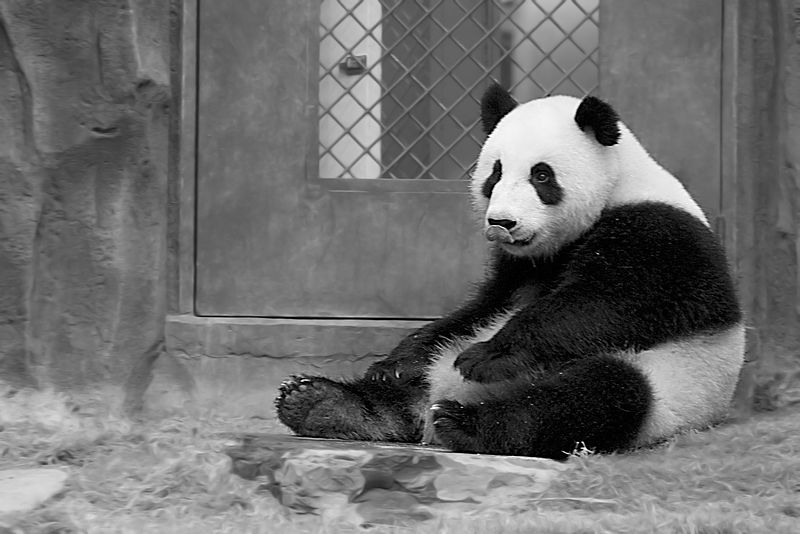

In [13]:
from PIL import Image
from IPython.display import display
cute_panda = Image.open('panda_bw.jpg')
display(cute_panda)

In [14]:
cute_panda_array = np.array(cute_panda)
cute_panda_array

array([[100, 100, 101, ..., 101, 102, 104],
       [108, 109, 108, ..., 100, 102, 104],
       [116, 116, 115, ...,  93,  96,  98],
       ...,
       [129, 128, 125, ..., 175, 176, 176],
       [129, 127, 123, ..., 163, 166, 168],
       [130, 127, 123, ..., 153, 159, 162]], shape=(534, 800), dtype=uint8)

In [15]:
full_array = np.full(cute_panda_array.shape, 255)
cute_panda_array_flipped = full_array - cute_panda_array 
cute_panda_array_flipped = cute_panda_array_flipped.astype(np.uint8)

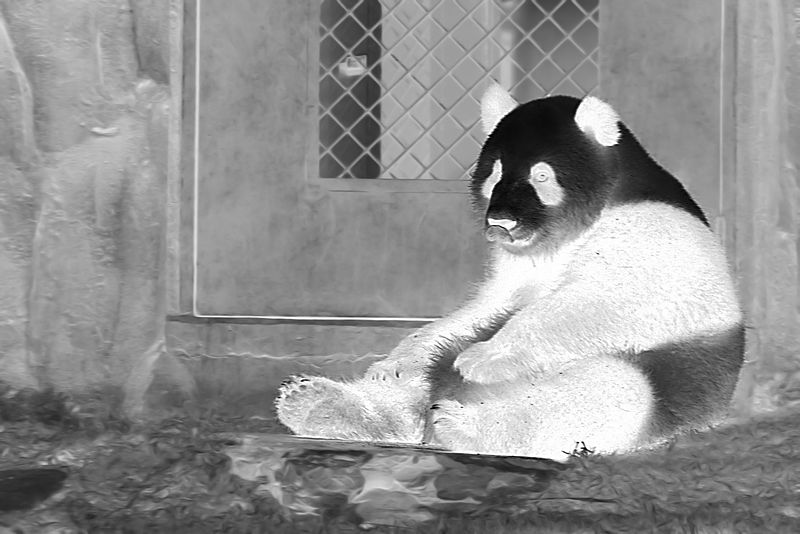

In [16]:
display(Image.fromarray(cute_panda_array_flipped))

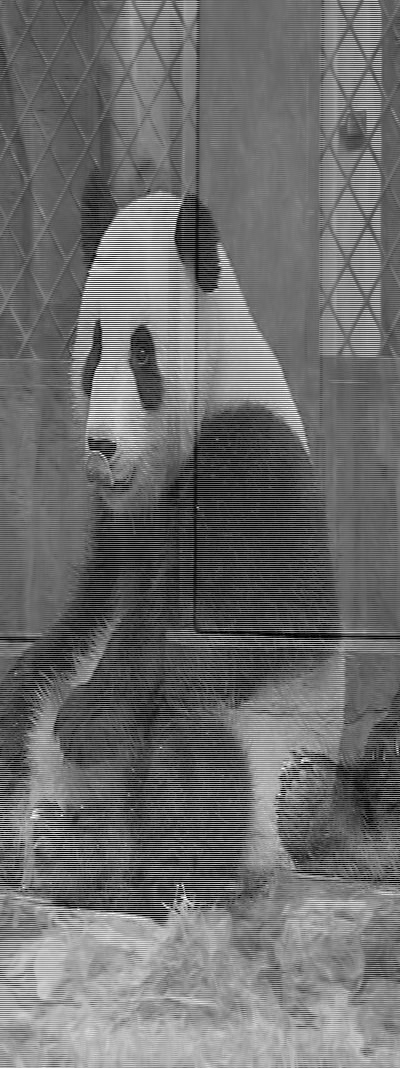

In [17]:
cute_panda_tall = np.reshape(cute_panda_array,(1068,400))
display(Image.fromarray(cute_panda_tall))

## Indexing and Slicing  
- Indexing: Extract a single element by specifying its location.  
   - array_1d[position_index]  
   - array_2d[row_index, column_index]  

- Slicing: Extract more than one element by specifying a range of locations or using a conditional (boolean slicing)  
   - array_1d[position indices]  
   - array_2d[row_indices, position_indices]   


### Indexing 1-d array  

- Extract a single element by specifying location index in square brackets  
- numpy array indices begin at 0  
- Negative indices count from the end of the array  

In [18]:
np.random.seed(617)
array_1d = np.array(np.random.randint(0,9,10))
array_1d

array([1, 2, 8, 6, 5, 5, 4, 1, 6, 6], dtype=int32)

In [19]:
array_1d[3]   # Extract element in 4th position
array_1d[-3]  # extract element in 3rd position from end

np.int32(1)

### Indexing 2-d array  

- Extract a single element by specifying row and column location index in square brackets separated by a comma  
- numpy array indices begin at 0  
- Negative indices count from the end of the array  

In [20]:
np.random.seed(617)
array_2d = np.random.randint(0,9,100).reshape(10,10)
array_2d

array([[1, 2, 8, 6, 5, 5, 4, 1, 6, 6],
       [2, 2, 5, 6, 4, 8, 1, 0, 3, 4],
       [8, 6, 1, 5, 0, 7, 4, 6, 1, 4],
       [1, 1, 6, 7, 0, 2, 1, 4, 2, 0],
       [4, 1, 0, 8, 8, 0, 1, 3, 4, 0],
       [4, 8, 6, 8, 8, 7, 8, 4, 3, 7],
       [5, 4, 7, 5, 2, 3, 1, 8, 1, 5],
       [4, 1, 1, 4, 5, 7, 5, 4, 0, 3],
       [6, 0, 7, 8, 7, 3, 8, 6, 3, 8],
       [8, 7, 4, 1, 3, 7, 0, 1, 0, 8]], dtype=int32)

In [21]:
array_2d[3,5]   # Extract element in 4th row and 6th column
array_2d[-1,-2]  # extract element in last row and second last column

np.int32(0)

### Slicing 1-d array  

- Extract more than one element  
- Specify more than one location as a list. [[1,2,3,4]]  
- Specify a range of locations. First element is included, last is not. [1:5]  
- Use colon to refer to everything before, or everything after. [:5]  
- Negative indexes to begin from the end [-9:-5]
  

In [22]:
np.random.seed(617)
array_1d = np.array(np.random.randint(0,9,10))
array_1d

array([1, 2, 8, 6, 5, 5, 4, 1, 6, 6], dtype=int32)

In [23]:
array_1d[[1,2,3,4]]  # array([2, 8, 6, 5])
array_1d[1:5]        # array([2, 8, 6, 5])
array_1d[-9:-5]      # array([2, 8, 6, 5])
array_1d[:5]         # array([1, 2, 8, 6, 5])

array([1, 2, 8, 6, 5], dtype=int32)

### Slicing 2-d array  

- Extract more than one element  
- Specify a range of locations for rows and columns. First element is included, last is not. [3:7,3:7]  
- Use colon to refer to everything before, or everything after. [:3,7:]  
- Negative indexes to begin from the end [-10:-7,-3:]  
- You can also slice with steps by specifying the start, end and step value separated by colon. [3:7:3,3:7:3]  

In [24]:
np.random.seed(617)
array_2d = np.random.randint(0,9,100).reshape(10,10)
array_2d

array([[1, 2, 8, 6, 5, 5, 4, 1, 6, 6],
       [2, 2, 5, 6, 4, 8, 1, 0, 3, 4],
       [8, 6, 1, 5, 0, 7, 4, 6, 1, 4],
       [1, 1, 6, 7, 0, 2, 1, 4, 2, 0],
       [4, 1, 0, 8, 8, 0, 1, 3, 4, 0],
       [4, 8, 6, 8, 8, 7, 8, 4, 3, 7],
       [5, 4, 7, 5, 2, 3, 1, 8, 1, 5],
       [4, 1, 1, 4, 5, 7, 5, 4, 0, 3],
       [6, 0, 7, 8, 7, 3, 8, 6, 3, 8],
       [8, 7, 4, 1, 3, 7, 0, 1, 0, 8]], dtype=int32)

In [25]:
array_2d[3:7,3:7]

array([[7, 0, 2, 1],
       [8, 8, 0, 1],
       [8, 8, 7, 8],
       [5, 2, 3, 1]], dtype=int32)

In [26]:
array_2d[:3,7:]

array([[1, 6, 6],
       [0, 3, 4],
       [6, 1, 4]], dtype=int32)

In [27]:
array_2d[-10:-7,-3:]

array([[1, 6, 6],
       [0, 3, 4],
       [6, 1, 4]], dtype=int32)

In [28]:
array_2d[3:7:3,3:7:3]

array([[7, 1],
       [5, 1]], dtype=int32)

In [29]:
arr = np.array([10,20,30,40])
arr[1]  # single index
arr[1:4]  # range of indices
arr[[1,2]] # specific indices
arr[arr>20]    # indexing using booleans or conditionals

array([30, 40])

In [30]:
arr_2d = np.array([[1,2,3,4],[5,6,7,8]]) 
arr_2d = np.arange(8).reshape(2,4)  # another way to create a 2-d array
# extract numbers 3 and 7
arr_2d[1,:]  # all elements in row2
arr_2d[:,1]  # all elements in col2
arr_2d[1,3]  # extract 7 which is in row 2 and column 3 
arr_2d[0:2,2:4]# extract 2,3 and 6,7
arr_2d[:1,:3]  # Slicing
arr_2d[:,1:2]  # Slicing

array([[1],
       [5]])

The array of the picture of the Panda can be also be sliced using integers. We can examine the shape and take out parts of the matrix that are not displaying the Panda. 

In [31]:
cute_panda_array.shape

(534, 800)

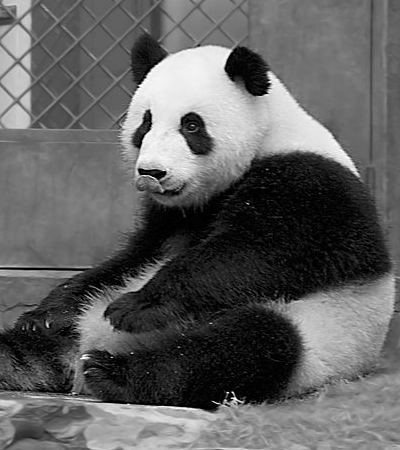

In [32]:
display(Image.fromarray(cute_panda_array[50:500,350:750]))

### Boolean Indexing
Arrays are subset based on a condition.

In [33]:
arr3 = np.array(['v','v','r','r','n','n','s','s'])
arr3[arr3 !='v']

array(['r', 'r', 'n', 'n', 's', 's'], dtype='<U1')

In [34]:
my_array = np.array([1,2,3,4,5,6,7,8,])
my_array[my_array>5]
my_array[my_array==5]

array([5])

Extract last three columns for all rows that have a value of greater than 4 in the first column.

In [35]:
array_2d[:,7:]  # Extract last three columns
array_2d[:,1]>4  # Elements in column 1 that are greater than 4
array_2d[array_2d[:,1]>4 , 7:]  # Putting it all together

array([[6, 1, 4],
       [4, 3, 7],
       [1, 0, 8]], dtype=int32)

### Find or Find and Replace  

- .np.where(condition) can be used to find an element in an ndarray  
- .np.where(condition, replacement, array) can also be used to find and replace the element  

Extract row and column indices for all values that are greater than equal to 8

In [36]:
np.where(array_2d>=7)

(array([0, 1, 2, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 7, 8, 8, 8, 8, 8, 9,
        9, 9, 9]),
 array([2, 5, 0, 5, 3, 3, 4, 1, 3, 4, 5, 6, 9, 2, 7, 5, 2, 3, 4, 6, 9, 0,
        1, 5, 9]))

Verify that those indices do in fact refer to numbers equal to or greater than 7

In [37]:
array_2d[np.where(array_2d>=7)]
array_2d

array([[1, 2, 8, 6, 5, 5, 4, 1, 6, 6],
       [2, 2, 5, 6, 4, 8, 1, 0, 3, 4],
       [8, 6, 1, 5, 0, 7, 4, 6, 1, 4],
       [1, 1, 6, 7, 0, 2, 1, 4, 2, 0],
       [4, 1, 0, 8, 8, 0, 1, 3, 4, 0],
       [4, 8, 6, 8, 8, 7, 8, 4, 3, 7],
       [5, 4, 7, 5, 2, 3, 1, 8, 1, 5],
       [4, 1, 1, 4, 5, 7, 5, 4, 0, 3],
       [6, 0, 7, 8, 7, 3, 8, 6, 3, 8],
       [8, 7, 4, 1, 3, 7, 0, 1, 0, 8]], dtype=int32)

Now, replace all those values that are greater than or equal to 7 with the number 999

In [38]:
np.where(array_2d>=7,999, array_2d)

array([[  1,   2, 999,   6,   5,   5,   4,   1,   6,   6],
       [  2,   2,   5,   6,   4, 999,   1,   0,   3,   4],
       [999,   6,   1,   5,   0, 999,   4,   6,   1,   4],
       [  1,   1,   6, 999,   0,   2,   1,   4,   2,   0],
       [  4,   1,   0, 999, 999,   0,   1,   3,   4,   0],
       [  4, 999,   6, 999, 999, 999, 999,   4,   3, 999],
       [  5,   4, 999,   5,   2,   3,   1, 999,   1,   5],
       [  4,   1,   1,   4,   5, 999,   5,   4,   0,   3],
       [  6,   0, 999, 999, 999,   3, 999,   6,   3, 999],
       [999, 999,   4,   1,   3, 999,   0,   1,   0, 999]], dtype=int32)

Lets have some fun with our Panda. We will replace all the really black spots (<25) with white (255).

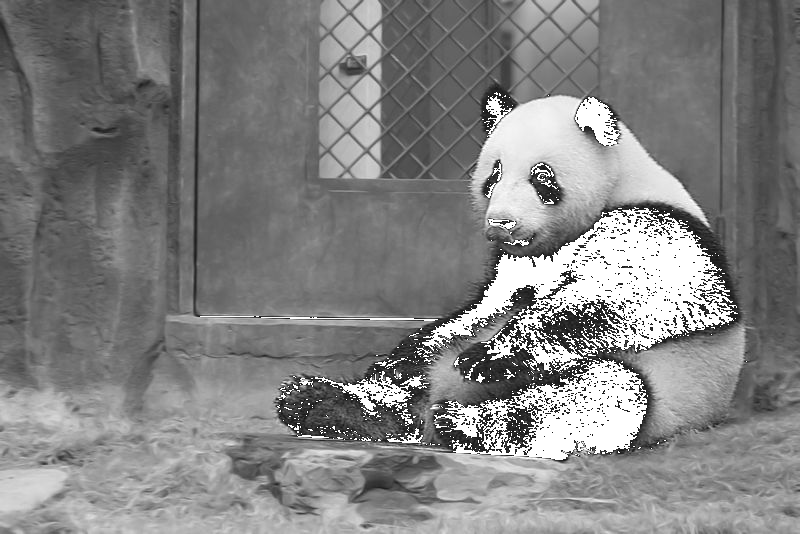

In [39]:
cute_panda_array_find_replace = np.where(cute_panda_array<25, 255,cute_panda_array)
display(Image.fromarray(cute_panda_array_find_replace))

## Useful numpy methods  

- .concatenate(): To combine two or more arrays with compatible shapes. Does not work with 1d arrays.   
- .delete(): Remove a column or row  
- .sort(): Sort a ndarray by rows (axis = 0) or columns (axis = 1)  
- .transpose(): swaps axes, essentially reshaping the data  
- .flip(): reverses the order of elements along a given axis  
- .stack(): Combine arrays by adding a new dimension  
- .split(): Split an array into multiple subarrays  

In [40]:
array1 = np.array([[1,2,3],
                   [4,5,6]])
array2 = np.array([[10,20],
                   [40,50]])
array3 = np.array([100,200])
print(array1)
print(array2)
print(array3)

[[1 2 3]
 [4 5 6]]
[[10 20]
 [40 50]]
[100 200]


### Concatenate

In [41]:
np.concatenate((array1, array2),axis = 1)   
# np.concatenate((array1,array3))  # will return error
np.concatenate((array1, array3.reshape(2,1)), axis=1)

array([[  1,   2,   3, 100],
       [  4,   5,   6, 200]])

### Delete

In [42]:
np.delete(array1,1,axis = 1)

array([[1, 3],
       [4, 6]])

### Sort

In [43]:
array_2d

array([[1, 2, 8, 6, 5, 5, 4, 1, 6, 6],
       [2, 2, 5, 6, 4, 8, 1, 0, 3, 4],
       [8, 6, 1, 5, 0, 7, 4, 6, 1, 4],
       [1, 1, 6, 7, 0, 2, 1, 4, 2, 0],
       [4, 1, 0, 8, 8, 0, 1, 3, 4, 0],
       [4, 8, 6, 8, 8, 7, 8, 4, 3, 7],
       [5, 4, 7, 5, 2, 3, 1, 8, 1, 5],
       [4, 1, 1, 4, 5, 7, 5, 4, 0, 3],
       [6, 0, 7, 8, 7, 3, 8, 6, 3, 8],
       [8, 7, 4, 1, 3, 7, 0, 1, 0, 8]], dtype=int32)

In [44]:
np.sort(array_2d,axis = 0)

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 4, 0, 2, 1, 1, 0, 0],
       [2, 1, 1, 5, 2, 3, 1, 1, 1, 3],
       [4, 1, 4, 5, 3, 3, 1, 3, 1, 4],
       [4, 2, 5, 6, 4, 5, 1, 4, 2, 4],
       [4, 2, 6, 6, 5, 7, 4, 4, 3, 5],
       [5, 4, 6, 7, 5, 7, 4, 4, 3, 6],
       [6, 6, 7, 8, 7, 7, 5, 6, 3, 7],
       [8, 7, 7, 8, 8, 7, 8, 6, 4, 8],
       [8, 8, 8, 8, 8, 8, 8, 8, 6, 8]], dtype=int32)

### Transposing Arrays and Swapping Axes

In [45]:
print(array1)
print('----')
print(np.transpose(array1))

[[1 2 3]
 [4 5 6]]
----
[[1 4]
 [2 5]
 [3 6]]


In [46]:
arr4 = np.arange(15).reshape(3,5)
print(arr4)
print('----')
print(np.transpose(arr4))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
----
[[ 0  5 10]
 [ 1  6 11]
 [ 2  7 12]
 [ 3  8 13]
 [ 4  9 14]]


### Flip

In [47]:
print(array1)
print('----')
print(np.flip(array1))

[[1 2 3]
 [4 5 6]]
----
[[6 5 4]
 [3 2 1]]


In [48]:
arr4 = np.arange(15).reshape(3,5)
print(arr4)
print('----')
print(np.flip(arr4))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
----
[[14 13 12 11 10]
 [ 9  8  7  6  5]
 [ 4  3  2  1  0]]


### Stack

In [49]:
np.random.seed(1031)
monthly_sales = np.random.randint(1000,10000,12)
q1_sales, q2_sales, q3_sales, q4_sales = np.split(monthly_sales, 4)
np.stack([q1_sales, q2_sales, q3_sales, q4_sales])

array([[1127, 6792, 6079],
       [3910, 7938, 7569],
       [6211, 1057, 7324],
       [8448, 7285, 6580]], dtype=int32)

In [50]:
np.stack([q1_sales.reshape(1,3), q2_sales.reshape(1,3)])

array([[[1127, 6792, 6079]],

       [[3910, 7938, 7569]]], dtype=int32)

## Computation on NumPy Arrays: Universal Functions  
Python’s default implementation (known as CPython) does some operations very slowly. This is partly due to the dynamic, interpreted nature of the language; types are flexible, so sequences of operations cannot be compiled down to efficient machine code as in languages like C and Fortran. This relative sluggishness of Python can generally be seen in situations where many small operations are being repeated; for instance, looping over arrays to operate on each element. 

For many types of operations, NumPy provides a convenient interface into just this kind of statically typed, compiled routine. This is known as a vectorized operation. For simple operations like the element-wise division here, vectorization is as simple as using Python arithmetic operators directly on the array object. This vectorized approach is designed to push the loop into the compiled layer that underlies NumPy, leading to much faster execution.

To illustrate, we will measure the time it takes for a loop and then a numpy ufunc to perform a computation. The task involves squaring 1000 numbers and adding them. 

In [51]:
numbers = np.arange(0,1e3,1)

In [52]:
def compute_squares(num):
    total = 0
    for i in num:
        total = total + num**2
    return(total)
%timeit compute_squares(numbers)

2.39 ms ± 719 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [53]:
%timeit np.sum(numbers**2)        

6.07 μs ± 1.61 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Ufuncs  

Vectorized operations in NumPy are implemented via ufuncs, whose main purpose is to quickly execute repeated operations on values in NumPy arrays. Ufuncs are extremely flexible. Here are a few commonly used Ufuncs. The names are intuitive.   

- Unary functions: mod, abs, sqrt, square, exp, log, log10, sign, ceil, floor, rint (round to the nearest integer), modf (return fractional and integeral parts of array), isnan (wether each value is NaN), isfinite, isinf, cos, cosh, sin, sinh, tan, tanh, logical_not  
- Binary functions: add, subtract, multiply, divide, floor_divide, power, maximum, minimum, mod, greater, greater_equal, less, less_equal, equal, not_equal, logical_and, logical_or, logical_xor.   
- Statistical Methods: sum, mean, std, var, min, max, cumsum, cumprod   
- Other Methods: sort, unique, intersect1d, union1d   

### Unary Methods and Binary functions 
NumPy’s ufuncs feel very natural to use because they make use of Python’s native arithmetic operators. All of these arithmetic operations are simply convenient wrappers around specific ufuncs built into NumPy. For example, the + operator is a wrapper for the np.add ufunc.

In [54]:
x = np.arange(10)
print("x      =", x)
print("x + 5  =", x + 5)
print("np.add(x, 5)  =", np.add(x, 5))
print("x - 5  =", x - 5)
print("x * 2  =", x * 2)
print("x / 2  =", x / 2)
print("x // 2 =", x // 2)  # floor division

x      = [0 1 2 3 4 5 6 7 8 9]
x + 5  = [ 5  6  7  8  9 10 11 12 13 14]
np.add(x, 5)  = [ 5  6  7  8  9 10 11 12 13 14]
x - 5  = [-5 -4 -3 -2 -1  0  1  2  3  4]
x * 2  = [ 0  2  4  6  8 10 12 14 16 18]
x / 2  = [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]
x // 2 = [0 0 1 1 2 2 3 3 4 4]


In [55]:
print("-x     = ", -x)
print("x**2 = ", x**2)
print("x % 2  = ", x % 2)
print("x cubed =", x**3)

-x     =  [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]
x**2 =  [ 0  1  4  9 16 25 36 49 64 81]
x % 2  =  [0 1 0 1 0 1 0 1 0 1]
x cubed = [  0   1   8  27  64 125 216 343 512 729]


In [56]:
print("abs(-x) =", np.abs(-x))
print("log(x+1) =", np.log(x+1))
print("exp(x) =", np.exp(x))
print("sin(x) =", np.sin(x))

abs(-x) = [0 1 2 3 4 5 6 7 8 9]
log(x+1) = [0.         0.69314718 1.09861229 1.38629436 1.60943791 1.79175947
 1.94591015 2.07944154 2.19722458 2.30258509]
exp(x) = [1.00000000e+00 2.71828183e+00 7.38905610e+00 2.00855369e+01
 5.45981500e+01 1.48413159e+02 4.03428793e+02 1.09663316e+03
 2.98095799e+03 8.10308393e+03]
sin(x) = [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155   0.6569866   0.98935825  0.41211849]


### Statistical Methods

In [57]:
np.random.seed(1031)
dat = np.random.randint(0,9,18).reshape(6,3)
dat

array([[5, 8, 0],
       [7, 0, 4],
       [8, 1, 7],
       [6, 5, 8],
       [6, 6, 4],
       [1, 6, 1]], dtype=int32)

In [58]:
print('column mean:', np.mean(dat,axis=0))
print('column variance:', np.var(dat,axis=0))
print('column standard deviation:', np.std(dat,axis=0))
print('column minimum:', np.min(dat,axis=0))
print('column maximum:', np.max(dat,axis=0))

column mean: [5.5        4.33333333 4.        ]
column variance: [4.91666667 8.22222222 8.33333333]
column standard deviation: [2.21735578 2.86744176 2.88675135]
column minimum: [1 0 0]
column maximum: [8 8 8]


Above Ufuncs can also be expressed as methods

In [59]:
print('column mean:', dat.mean(axis = 0))
print('column variance:', dat.var(axis = 0))
print('column standard deviation:', dat.std(axis=0))
print('column minimum:', dat.min(axis=0))
print('column maximum:', dat.max(axis=0))

column mean: [5.5        4.33333333 4.        ]
column variance: [4.91666667 8.22222222 8.33333333]
column standard deviation: [2.21735578 2.86744176 2.88675135]
column minimum: [1 0 0]
column maximum: [8 8 8]


### Other methods

In [60]:
arr6 = np.array([2,4,1,5,9,6])
np.sort(arr6)

array([1, 2, 4, 5, 6, 9])

In [61]:
np.unique(np.array([1,1,2,2,2,2,3]))

array([1, 2, 3])

### Example 
Here is an illustration that leverages Numpy Arrays to perform a simple operation of converting height and weight to standard units. 

In [62]:
id = [1,2,3,4,5,6,7,8,9,10]
height_in = [64,70,74,66,65,66,69,72,72,71]
weight_lbs = [150,170,160,180,200,220,190,180,190,200]
matrix = np.column_stack([id, height_in, weight_lbs])
matrix

array([[  1,  64, 150],
       [  2,  70, 170],
       [  3,  74, 160],
       [  4,  66, 180],
       [  5,  65, 200],
       [  6,  66, 220],
       [  7,  69, 190],
       [  8,  72, 180],
       [  9,  72, 190],
       [ 10,  71, 200]])

In [63]:
convert = np.array([1,0.0254,0.4545])
matrix * convert

array([[ 1.    ,  1.6256, 68.175 ],
       [ 2.    ,  1.778 , 77.265 ],
       [ 3.    ,  1.8796, 72.72  ],
       [ 4.    ,  1.6764, 81.81  ],
       [ 5.    ,  1.651 , 90.9   ],
       [ 6.    ,  1.6764, 99.99  ],
       [ 7.    ,  1.7526, 86.355 ],
       [ 8.    ,  1.8288, 81.81  ],
       [ 9.    ,  1.8288, 86.355 ],
       [10.    ,  1.8034, 90.9   ]])

In [64]:
np.corrcoef(matrix[:,1],matrix[:,2])

array([[ 1.        , -0.13422827],
       [-0.13422827,  1.        ]])

### Another Example
We will import a dataset of white wines using np.genfromtxt. This dataset contains the following columns: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality


In [65]:
wine = np.genfromtxt(fname = 'winequality-white.csv', 
                          dtype = float, 
                          delimiter = ';', 
                          encoding = None, skip_header=1)
wine.shape

(4898, 12)

Lets find the average quality and average alcohol

In [66]:
avg_quality = wine[:,-1].mean()
avg_quality

np.float64(5.87790935075541)

In [67]:
avg_alcohol = wine[:,-2].mean()
avg_alcohol

np.float64(10.514267047774602)

Now, lets see if wines with more alcohol than average are deemed above average in quality.

In [68]:
avg_quality_above_avg_alcohol = wine[wine[:,-2] > avg_alcohol,-1].mean()
avg_quality_above_avg_alcohol

np.float64(6.261211280628756)

## Conclusion   
This note examined the key features of numpy and its use for slicing, data manipulation and summarization.